# Когда-нибудь это закончится? Симуляция распространения болезни. Работа с NetworkX
Набор данных представляет собой основные маршруты авиаперелетов в США за один месяц 2008-го года. В качестве модели распространения инфекции предлагается использовать SI (susceptible-infected) модель, в которой каждый аэропорт имеет два возможных состояния - “здоровый” или “зараженный”. Здоровый аэропорт может заразиться с некоторой вероятностью p (infection probability), если к нему прилетает самолет из зараженного города. Инфекция начинает распространение из некоторого стартового аэропорта и заканчивает распространение, когда все перелеты из датасета завершены.

https://www.kaggle.com/datasets/vikalpdongre/us-flights-data-2008

## Часть 1. Пишем симуляцию.
* Напишите функцию для симуляции одного прохода по всему датасету и распространения инфекции. Функция должна принимать на вход стартовый город, в котором изначально началась инфекция и вероятность распространения инфекции p. На выходе функция должна возвращать словарь, в котором ключом будет время заражения аэропорта, значением - название аэропорта. В теле функции вам нужно написать проход по всему датасету (имеет смысл использовать itertuples), где вы будете проверять, является ли текущий рейс “заразным” и если да - с вероятностью p заражать новый аэропорт.
* В качестве стартовой ноды/аэропорта для симуляций можно использовать Allentown (node_id = 0).

## Часть 2. Как инфекционность (вероятность заражения) болезни влияет на скорость распространения?
* Давайте посмотрим, насколько заразной должна быть болезнь, чтобы заразить все аэропорты в сети. Для каждой из вероятностей p=[0.01, 0.05, 0.1, 0.5, 1.] прогоните по 10 симуляций распространения, каждый раз сохраняя результаты.
* Для каждых 12 часов симуляции посчитайте, какой средний процент аэропортов от общего их числа, был заражен к этому моменту времени. Постройте графики числа зараженных городов в зависимости от времени для каждой из вероятностей.

## Часть 3. Может ли информация о сети помочь предсказать, кто будет заражен?
* Настало время поработать с NetworkX. По имеющемуся датасету вам нужно построить ненаправленный граф всех аэропортов, используя относительное число перелетов между соседними аэропортами в качестве веса ребра. Например, если из аэропорта А в аэропорт Б суммарно есть 5 рейсов, из Б в А 10 рейсов, а всего в сети 150 перелетов, то вес ребра между А и Б должен быть равен (5+10)/150 = 0.1.
* Прогоните вашу симуляцию 50 раз, используя p=0.5 и стартовый аэропорт Allentown, каждый раз сохраняя результаты. Используя данные симуляций посчитайте медианное время до заражения каждого города.
* Теперь используя построенный вами граф, для каждого города посчитайте его коэффициент кластеризации (nx.clustering), степень (nx.degree) и центральность (nx.betweenness_centrality).
* Наконец, постройте scatter-plot-ы для медианного времени заражения и каждой из рассчитанных выше метрик. Также посчитайте коэффициент корреляции Спирмана между этими показателями и попробуйте проинтерпретировать полученные результаты. Какая из метрик графа сильнее всего скоррелирована со временем заражения? Почему?

In [1]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import math

# Импорт библиотеки для работы с сетевыми структурами
import networkx as nx

# Импорт библиотеки построения диаграмм и графиков
from matplotlib import pyplot as plt
import seaborn as sns

from collections import defaultdict

In [3]:
flights_df = pd.read_csv("HW4(lesson13)_data.csv")

# Подготовка данных

In [4]:
flights_df.head(3).T

,0,1,2
Year,2008,2008,2008
Month,1,1,1
DayofMonth,3,3,3
DayOfWeek,4,4,4
DepTime,2003.0,754.0,628.0
CRSDepTime,1955,735,620
ArrTime,2211.0,1002.0,804.0
CRSArrTime,2225,1000,750
UniqueCarrier,WN,WN,WN
FlightNum,335,3231,448


In [5]:
# нас интересуют данные о дате и времени вылета, продолжительности авиарейса, аэропортах вылета и прилета.
# так же возьмем информацию об отмене рейсов.
col_lst = ["Year", "Month", "DayofMonth", "CRSDepTime", "CRSElapsedTime", "Origin", "Dest", "Cancelled"]
flights_df = flights_df[col_lst]

# переименовываем столбцы аэропортов вылета и прилета
flights_df = flights_df.rename(columns={"Origin": "DepartureAirport", "Dest": "ArrivalAirport"})

# удалим информацию об отмененных рейсах и удалим столбец об отменах за ненадобностью
flights_df = flights_df[flights_df["Cancelled"] == 0]
flights_df = flights_df.drop(["Cancelled"], axis="columns")

In [6]:
flights_df.head(3).T

,0,1,2
Year,2008,2008,2008
Month,1,1,1
DayofMonth,3,3,3
CRSDepTime,1955,735,620
CRSElapsedTime,150.0,145.0,90.0
DepartureAirport,IAD,IAD,IND
ArrivalAirport,TPA,TPA,BWI


In [7]:
flights_df.isnull().sum()

Year                  0
Month                 0
DayofMonth            0
CRSDepTime            0
CRSElapsedTime      598
DepartureAirport      0
ArrivalAirport        0
dtype: int64

In [8]:
# пропусков немного, просто удалим их (можно было посчитать из фактических данных рейса, но не вижу смысла)
flights_df = flights_df.dropna()

In [9]:
flights_df.info()

<class 'pandas.DataFrame'>
Index: 6871696 entries, 0 to 7009727
Data columns (total 7 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Year              int64  
 1   Month             int64  
 2   DayofMonth        int64  
 3   CRSDepTime        int64  
 4   CRSElapsedTime    float64
 5   DepartureAirport  str    
 6   ArrivalAirport    str    
dtypes: float64(1), int64(4), str(2)
memory usage: 419.4 MB


In [10]:
# собираем время вылета и удаляем исходные столбцы
flights_df["DepartureTimeStamp"] = pd.to_datetime({
    "year": flights_df["Year"],
    "month": flights_df["Month"],
    "day": flights_df["DayofMonth"],
    "hour": flights_df["CRSDepTime"].astype(int) // 100,
    "minute": flights_df["CRSDepTime"].astype(int) % 100
})
flights_df = flights_df.drop(["Year", "Month", "DayofMonth", "CRSDepTime"], axis="columns")

# собираем время прилета и удаляем столбец продолжительности рейса
flights_df["ArrivalTimeStamp"] = flights_df["DepartureTimeStamp"] + pd.to_timedelta(flights_df["CRSElapsedTime"], unit="min")
flights_df = flights_df.drop(["CRSElapsedTime"], axis="columns")

In [11]:
column_names = [
    "ID", "name", "city", "country", "IATACode", "icao",
    "latitude", "longitude", "altitude_ft", "TimeZone",
    "dst", "tz_database_time_zone", "type", "source"
]

# таблица аэропортов с openflights.org
airports_df = pd.read_csv("airports.csv", header=None, names=column_names)
# удаляем не интересующие нас записи
airports_df = airports_df[["ID", "IATACode", "TimeZone"]]
airports_df = airports_df[airports_df["IATACode"] != "\\N"]
airports_df = airports_df[airports_df["TimeZone"] != "\\N"]

# проверяем что информация найдена по всем интересующим нас аэропортам
airport_cols = ["DepartureAirport", "ArrivalAirport"]
airports_lst = pd.concat([flights_df[col] for col in airport_cols]).unique()
unknown_airports_lst = list(set(airports_lst) - set(airports_df["IATACode"]))
print(f"неизвестных аэропортов: {len(unknown_airports_lst)} {unknown_airports_lst}")

неизвестных аэропортов: 0 []


In [12]:
# приводим время к абсолютному с учетом часового пояса аэропорта
airports_df["TimeZone"] = pd.to_numeric(airports_df["TimeZone"])
airport_time_idx = airports_df.set_index("IATACode")["TimeZone"]
flights_df["DepartureTimeStamp"] = (flights_df["DepartureTimeStamp"] +
                        pd.to_timedelta(flights_df["DepartureAirport"].map(airport_time_idx), unit="hour"))
flights_df["ArrivalTimeStamp"] = (flights_df["ArrivalTimeStamp"] +
                        pd.to_timedelta(flights_df["ArrivalAirport"].map(airport_time_idx), unit="hour"))

# меняем строковый код аэропорта на числовой (это должно облегчить и ускорить дальнейшие вычисления)
airport_id_idx = airports_df.set_index("IATACode")["ID"]
flights_df["DepartureAirportID"] = flights_df["DepartureAirport"].map(airport_id_idx)
flights_df["ArrivalAirportID"] = flights_df["ArrivalAirport"].map(airport_id_idx)
flights_df = flights_df.drop(["DepartureAirport", "ArrivalAirport"], axis="columns")

In [13]:
# сортируем по времени вылета, поскольку нам важна будет хронология событий
flights_df = flights_df.sort_values("DepartureTimeStamp")

# Симуляция распространения

In [14]:
def process_simulation(flights: pd.DataFrame, airport:int64, probability:float) -> dict:
    # для удобства поиска ключем является аэропорт
    first_infection = flights[flights["DepartureAirportID"] == airport].iloc[0]["DepartureTimeStamp"]
    infected = {airport: first_infection}
    for flight in flights.itertuples(index=False):
        # порог заражения
        threshold = np.random.uniform()
        # проверяем что:
        #  - порог заражения превышает вероятность заражения
        #  - аэропорт прилета еще не заражен (что бы не обновлять время заражения)
        #  - аэропорт вылета заражен
        #  - аэропорт вылета был заражен раньше времени вылета
        #       (возможно, аэропорт вылета уже был помечен зараженным, но заражающий рейс еще не приземлился)
        if ((threshold <= probability) and (flight.ArrivalAirportID not in infected) and
                (flight.DepartureAirportID in infected) and (infected[flight.DepartureAirportID] <= flight.DepartureTimeStamp)):
            infected[flight.ArrivalAirportID] = flight.ArrivalTimeStamp
    # по заданию я должен вернуть ключем время (это удобно для сортировки по времени)
    # но приходится учитывать, что время может и совпадать (а потом придется учитыать, что value это list)
    result = defaultdict(list)
    for key, value in infected.items():
        result[value].append(key)
    return dict(result)

In [15]:
infected_dict = process_simulation(flights_df, flights_df.iloc[0]["DepartureAirportID"], 0.001)
infected_count = sum(len(infected_on_time) for infected_on_time in infected_dict.values())
airport_total_count = pd.concat([flights_df["DepartureAirportID"], flights_df["ArrivalAirportID"]]).unique().shape[0]
print(f"заражено {infected_count} из {airport_total_count}")

заражено 239 из 305


# Скорость распространения

In [16]:
iteration_dict = {}
def collect_statistic(flights: pd.DataFrame, airport:int64, probability_coll:list[int], iteration_count:int) -> pd.DataFrame:
    results = pd.DataFrame()
    for probability in probability_coll:
        for iteration_ind in range(iteration_count):
            simulation_result = process_simulation(flights, airport, probability)
            global iteration_dict
            iteration_dict = simulation_result
            iteration_result = pd.Series(simulation_result).explode().reset_index()
            iteration_result.columns = ["Время заражения", "Заражен аэропорт"]
            iteration_result = iteration_result.assign(**{
                    "Номер итерации": iteration_ind + 1,
                    "Вероятность": probability
                })
            results = pd.concat([results, iteration_result])
    return results

In [17]:
MAKE_STATISTIC_LST = False
STATISTIC_LST_FILE_PATH = "statistic_lst.pkl"
if MAKE_STATISTIC_LST:
    probability_lst=[0.01, 0.05, 0.1, 0.5, 1.0]
    statistic_lst_df = collect_statistic(flights_df, flights_df.iloc[0]["DepartureAirportID"], probability_lst, 10)
    statistic_lst_df.to_pickle(STATISTIC_LST_FILE_PATH)
else:
    statistic_lst_df = pd.read_pickle(STATISTIC_LST_FILE_PATH)


In [18]:
datetime_increment = pd.to_timedelta(12, unit="hour")
infection_period = pd.date_range(
    start=statistic_lst_df["Время заражения"].min(),
    end=statistic_lst_df["Время заражения"].max(),
    freq=f"{datetime_increment.value}ns"
)

airport_total_count = pd.concat([flights_df["DepartureAirportID"], flights_df["ArrivalAirportID"]]).unique().shape[0]
infection_progress_dict = {}
for current_datetime in infection_period:
    infected_by_datetime_mask = statistic_lst_df["Время заражения"] <= current_datetime
    infected_by_datetime_all = statistic_lst_df[infected_by_datetime_mask].groupby(["Номер итерации", "Вероятность"]).count() / airport_total_count
    infected_by_datetime_mean = infected_by_datetime_all.reset_index().groupby("Вероятность").mean()["Заражен аэропорт"]
    infection_progress_dict[current_datetime] = dict(infected_by_datetime_mean)


In [19]:
airport_total_count = pd.concat([flights_df["DepartureAirportID"], flights_df["ArrivalAirportID"]]).unique().shape[0]
current_datetime = statistic_lst_df["Время заражения"].max()

infected_by_datetime_mask = statistic_lst_df["Время заражения"] <= current_datetime
infected_by_datetime_all = statistic_lst_df[infected_by_datetime_mask].groupby(["Номер итерации", "Вероятность"]).count() / airport_total_count
infected_by_datetime_mean = infected_by_datetime_all.reset_index().groupby("Вероятность").mean()["Заражен аэропорт"]
dict(infected_by_datetime_mean)

{0.01: np.float64(0.9665573770491804),
 0.05: np.float64(0.9859016393442623),
 0.1: np.float64(0.9881967213114754),
 0.5: np.float64(0.9954098360655739),
 1.0: np.float64(0.9967213114754099)}

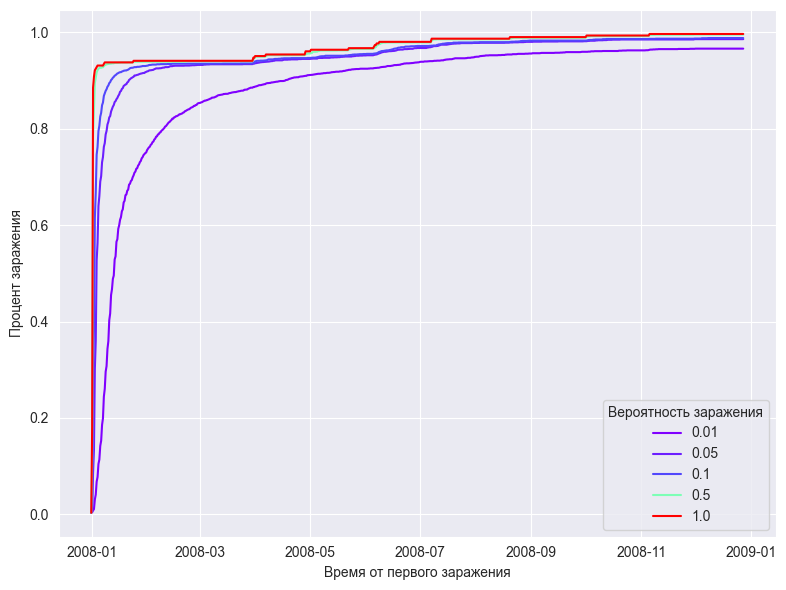

In [20]:
infection_progress_df = pd.DataFrame.from_dict(infection_progress_dict, orient="index")
view_df = infection_progress_df.reset_index().melt(id_vars="index", var_name="Вероятность заражения", value_name="Процент заражения")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.lineplot(data=view_df, ax=ax, x="index", y="Процент заражения", hue="Вероятность заражения", palette="rainbow")
ax.set_xlabel("Время от первого заражения")
plt.tight_layout()
plt.show()

# NetworkX

In [21]:
mask = flights_df["DepartureAirportID"] < flights_df["ArrivalAirportID"]
edges_df = pd.DataFrame({
    "first": np.where(mask,flights_df["DepartureAirportID"], flights_df["ArrivalAirportID"]),
    "second": np.where(mask,flights_df["ArrivalAirportID"], flights_df["DepartureAirportID"]),
    "weight": 1
})
weighted_df = edges_df.groupby(["first", "second"])["weight"].sum() / flights_df.shape[0]
weighted_df = weighted_df.reset_index()

# для рисования ноды хотелось бы иметь человекочитаемое представление
airport_id_idx = airports_df.set_index("ID")["IATACode"]
weighted_df["first"] = weighted_df["first"].map(airport_id_idx)
weighted_df["second"] = weighted_df["second"].map(airport_id_idx)


In [22]:
nx_graph = nx.from_pandas_edgelist(
    weighted_df,
    source="first",
    target="second",
    edge_attr="weight",
    create_using=nx.Graph()
)
print(f"узлов: {nx_graph.number_of_nodes()}")
print(f"ребер: {nx_graph.number_of_edges()}")

узлов: 305
ребер: 2820


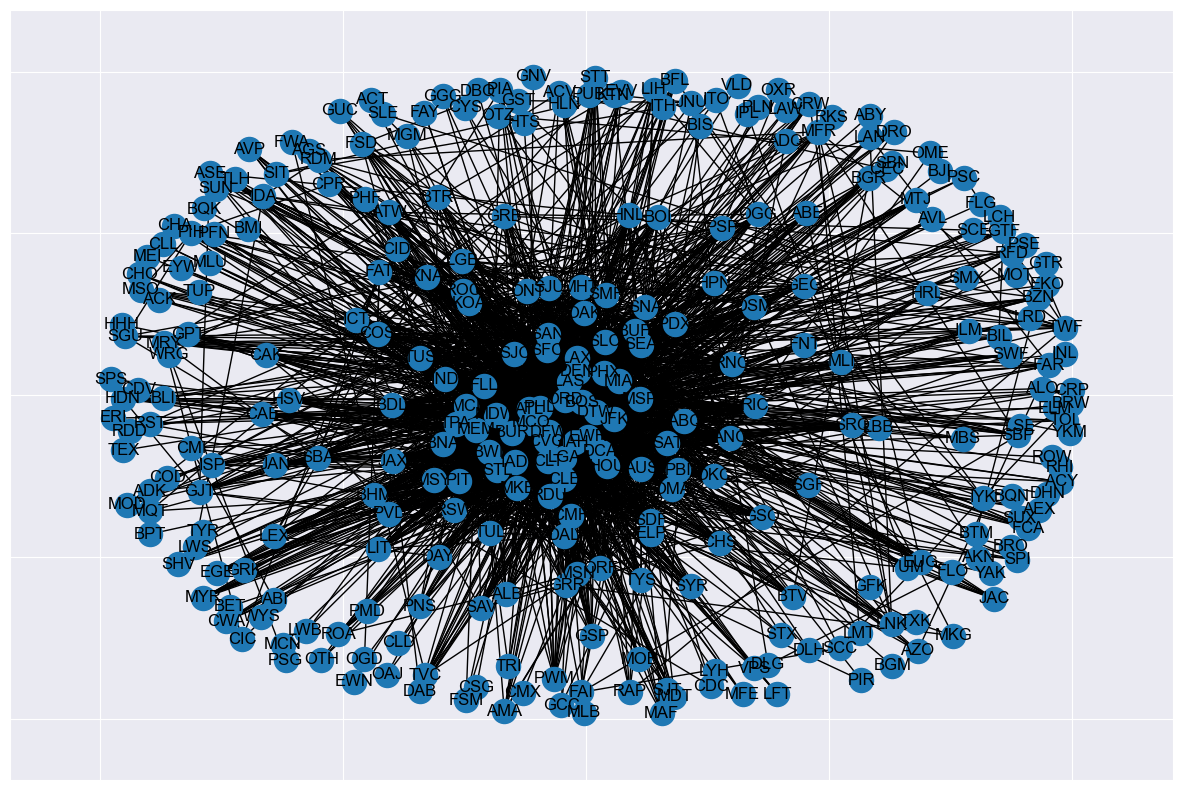

In [23]:
fig = plt.figure(1, figsize=(15, 10))
nx.draw_networkx(nx_graph)
plt.show()

In [24]:
MAKE_STATISTIC_ONE = False
STATISTIC_ONE_FILE_PATH = "statistic_one.pkl"
if MAKE_STATISTIC_ONE:
    staticstic_one_df = collect_statistic(flights_df, flights_df.iloc[0]["DepartureAirportID"], [0.5], 50)
    staticstic_one_df.to_pickle(STATISTIC_ONE_FILE_PATH)
else:
    staticstic_one_df = pd.read_pickle(STATISTIC_ONE_FILE_PATH)

In [25]:
infection_first_datetime = staticstic_one_df["Время заражения"].min()
staticstic_one_df["delay"] = staticstic_one_df["Время заражения"] - infection_first_datetime
median_time = pd.DataFrame(staticstic_one_df.groupby("Заражен аэропорт")["delay"].median()).reset_index()
median_time["Заражен аэропорт"] = median_time["Заражен аэропорт"].map(airport_id_idx)
median_time = median_time.set_index("Заражен аэропорт")

In [26]:
# посчитаем метрики
clustering = nx.clustering(nx_graph, weight="weight")
degree = dict(nx_graph.degree(weight="weight"))
centrality = nx.betweenness_centrality(nx_graph, weight="weight")

node_metrics_df = pd.DataFrame.from_dict(clustering, orient="index", columns=["clustering"]).join([
    pd.DataFrame.from_dict(degree ,orient="index", columns=["degree"]),
    pd.DataFrame.from_dict(centrality ,orient="index", columns=["centrality"]),
    median_time
])
node_metrics_df["delay_hour"] = node_metrics_df["delay"].dt.total_seconds() / 3600
node_metrics_df.sort_values("clustering", ascending=False)

,clustering,degree,centrality,delay,delay_hour
LFT,0.179625,0.001375,0.0,0 days 15:02:00,15.033333
LAW,0.159910,0.000673,0.0,0 days 16:25:00,16.416667
ITO,0.145846,0.002331,0.0,0 days 14:49:00,14.816667
GRK,0.140541,0.001049,0.0,0 days 16:45:00,16.750000
MOB,0.135878,0.001792,0.0,0 days 14:50:00,14.833333
...,...,...,...,...,...
CMX,0.000000,0.000082,0.0,3 days 02:25:00,74.416667
BJI,0.000000,0.000021,0.0,156 days 18:05:00,3762.083333
BQK,0.000000,0.000264,0.0,0 days 19:39:00,19.650000
LYH,0.000000,0.000178,0.0,0 days 23:57:00,23.950000


In [27]:
node_metrics_df.describe()

,clustering,degree,centrality,delay,delay_hour
count,305.000000,3.050000e+02,305.000000,304,304.000000
mean,0.040353,6.557377e-03,0.017780,9 days 18:00:15.493421,234.004304
std,0.034120,1.433946e-02,0.034315,39 days 08:32:42.519528,944.545144
min,0.000000,2.910490e-07,0.000000,0 days 00:00:00,0.000000
25%,0.012194,3.659941e-04,0.000000,0 days 14:13:30,14.225000
50%,0.038027,1.191263e-03,0.000000,0 days 16:57:30,16.958333
75%,0.059696,4.646306e-03,0.019595,0 days 19:51:15,19.854167
max,0.179625,1.188158e-01,0.219397,313 days 01:10:00,7513.166667


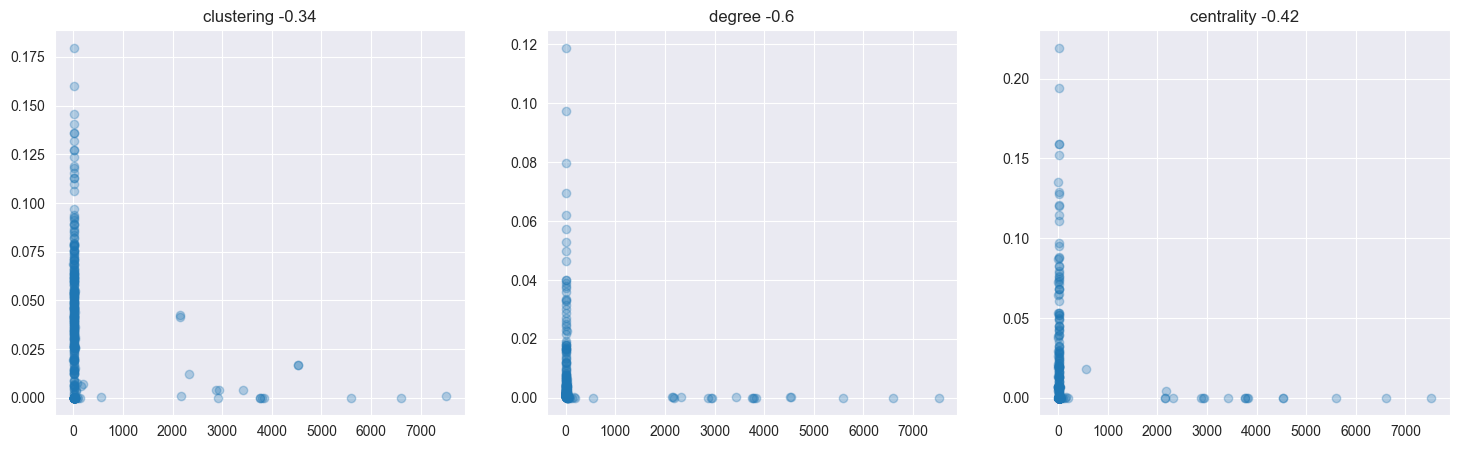

In [32]:
corr_df = node_metrics_df.drop("delay", axis="columns").corr("spearman").loc["delay_hour"]
metrics_df = node_metrics_df.drop("delay", axis="columns").reset_index().melt(id_vars=["index", "delay_hour"], var_name="metric")

metrics = metrics_df["metric"].unique()
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), sharex=True)
for ax, metric in zip(axes, metrics):
    subset = metrics_df[metrics_df["metric"] == metric]
    ax.scatter(subset["delay_hour"], subset["value"], alpha=0.3)
    ax.set_title(f"{metric} {round(corr_df[metric], 2)}")
plt.show()

Clustering rs = -0.34

Degree rs = − 0.6

Centrality rs = −0.42

Все значения отрицательные, т.е. чем более изолирован узел, тем больше времени до его заражения

При этом наибольшее значение имеет общее количество соседей (что тоже логично, поскольку даже один рейс из зараженного узла имеет шанс к заражению)